**Mashalov Rasulbek, OSTC2U, Machine Learning, HomeWork 11, 30th April, 2026**

In [62]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import warnings
import numpy as np
import cv2
from sklearn.cluster import MiniBatchKMeans

warnings.filterwarnings('ignore')

**EXERCISE 1**

In [63]:
X, y = make_blobs(n_samples=500, n_features=2, centers=5, random_state=42)

k_values = range(1, 21)
inertias = []

for k in k_values:
    #setting n_init='auto' to get best possible initialization.
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    print(f"K = {k}: Inertia = {kmeans.inertia_:.2f}")

K = 1: Inertia = 30210.77
K = 2: Inertia = 14726.12
K = 3: Inertia = 3648.76
K = 4: Inertia = 1543.39
K = 5: Inertia = 924.10
K = 6: Inertia = 856.80
K = 7: Inertia = 776.02
K = 8: Inertia = 721.07
K = 9: Inertia = 647.10
K = 10: Inertia = 592.39
K = 11: Inertia = 577.39
K = 12: Inertia = 523.20
K = 13: Inertia = 499.45
K = 14: Inertia = 463.95
K = 15: Inertia = 417.54
K = 16: Inertia = 382.88
K = 17: Inertia = 355.60
K = 18: Inertia = 336.18
K = 19: Inertia = 324.52
K = 20: Inertia = 310.65


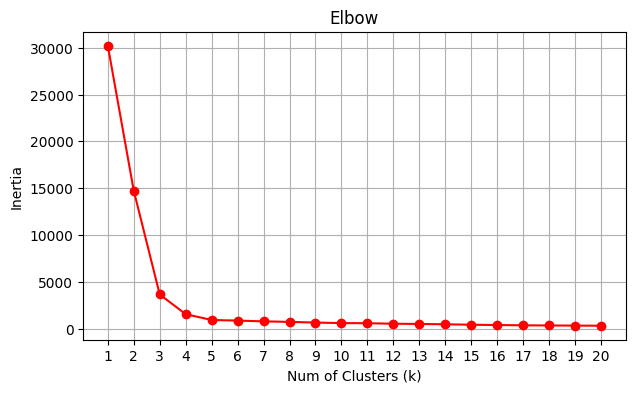

In [64]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker='o', linestyle='-', color='red')
plt.title('Elbow')
plt.xlabel('Num of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

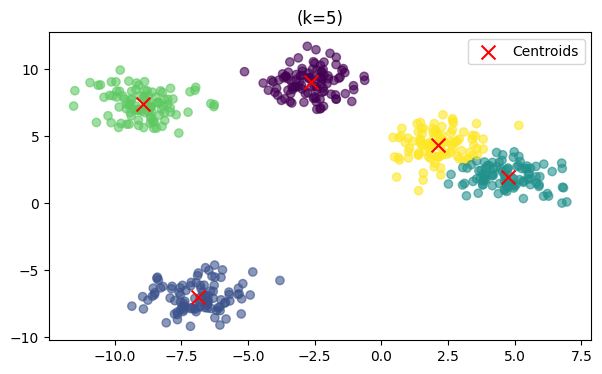

In [65]:
best_k = 5

best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
best_kmeans.fit(X)

plt.figure(figsize=(7, 4))
plt.scatter(X[:, 0], X[:, 1], c=best_kmeans.labels_, cmap='viridis', marker='o', alpha=0.6)
plt.scatter(best_kmeans.cluster_centers_[:, 0], best_kmeans.cluster_centers_[:, 1], c='red', marker='x', s=100, label='Centroids')
plt.title(f'(k={best_k})')
plt.legend()
plt.show()

**EXERCISE 2**

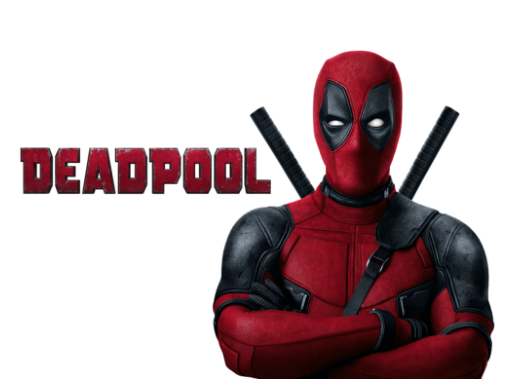

In [66]:
img_path = "/content/drive/MyDrive/mL_unideb/deadpool.png"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
(h, w) = image.shape[:2]
pixels = image.reshape((h * w, 3))

plt.figure()
plt.axis("off")
plt.imshow(image)

In [67]:
k_values = range(2, 11)
inertias = []

for k in k_values:
    model = MiniBatchKMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(pixels)
    inertias.append(model.inertia_)

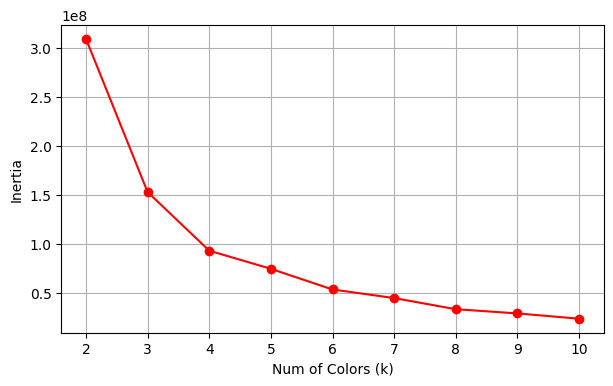

In [68]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker='o', linestyle='-', color='r')
plt.xlabel('Num of Colors (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [71]:
best_k = 5

final_model = MiniBatchKMeans(n_clusters=best_k, random_state=42, n_init='auto')
labels = final_model.fit_predict(pixels)

quant_pixels = np.zeros((len(labels), 3), dtype=np.uint8)

for i in range(len(labels)):
    quant_pixels[i] = final_model.cluster_centers_[labels[i]].astype("uint8")

quant_image = quant_pixels.reshape((h, w, 3))

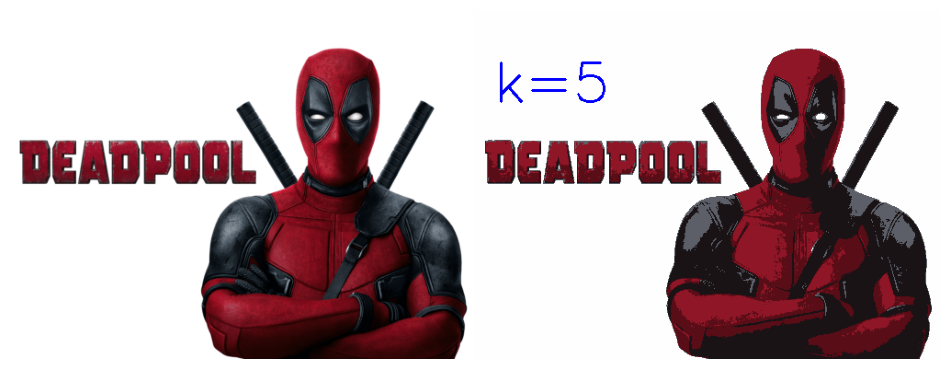

In [72]:
cv2.putText(quant_image, f"k={best_k}", (20, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 2)

out_image = np.hstack([image, quant_image])

plt.figure(figsize=(12, 6))
plt.axis("off")
plt.imshow(out_image)
plt.show()